In [1]:
# ============================================================
# CELL 1: INSTALL REQUIRED LIBRARIES
# ============================================================

!pip -q install nltk wordcloud seaborn joblib

In [23]:
import os, re, zipfile, joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from collections import Counter

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from wordcloud import WordCloud

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, classification_report, confusion_matrix
)

nltk.download("stopwords")
nltk.download("wordnet")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [24]:
from google.colab import files

uploaded = files.upload()
zip_file = next(iter(uploaded))

with zipfile.ZipFile(zip_file, "r") as z:
    z.extractall("agnews")

# Find CSV files
train_path = "agnews/train.csv"
test_path = "agnews/test.csv"

train = pd.read_csv(train_path)
test = pd.read_csv(test_path)

train.columns = ["label", "title", "description"]
test.columns = ["label", "title", "description"]

print("Training data:", train.shape)
print("Test data:", test.shape)

display(train.head())

Saving archive (5).zip to archive (5) (2).zip
Training data: (120000, 3)
Test data: (7600, 3)


,label,title,description
0,3,Wall St. Bears Claw Back Into the Black (Reuters),"Reuters - Short-sellers, Wall Street's dwindli..."
1,3,Carlyle Looks Toward Commercial Aerospace (Reu...,Reuters - Private investment firm Carlyle Grou...
2,3,Oil and Economy Cloud Stocks' Outlook (Reuters),Reuters - Soaring crude prices plus worries\ab...
3,3,Iraq Halts Oil Exports from Main Southern Pipe...,Reuters - Authorities have halted oil export\f...
4,3,"Oil prices soar to all-time record, posing new...","AFP - Tearaway world oil prices, toppling reco..."


In [25]:
label_map = {
    1: "World",
    2: "Sports",
    3: "Business",
    4: "Sci/Tech"
}

train["category"] = train["label"].map(label_map)
test["category"] = test["label"].map(label_map)

print("Number of records:", len(train))
print("Number of columns:", len(train.columns))

print("\nMissing values:")
print(train.isnull().sum())

print("\nDuplicate rows:", train.duplicated().sum())

print("\nArticles per category:")
print(train["category"].value_counts())

print("\nClass balance (%):")
print((train["category"].value_counts(normalize=True) * 100).round(2))

Number of records: 120000
Number of columns: 4

Missing values:
label          0
title          0
description    0
category       0
dtype: int64

Duplicate rows: 0

Articles per category:
category
Business    30000
Sci/Tech    30000
Sports      30000
World       30000
Name: count, dtype: int64

Class balance (%):
category
Business    25.0
Sci/Tech    25.0
Sports      25.0
World       25.0
Name: proportion, dtype: float64


In [26]:
train[["title", "description"]] = train[["title", "description"]].fillna("")
test[["title", "description"]] = test[["title", "description"]].fillna("")

train["text"] = train["title"] + " " + train["description"]
test["text"] = test["title"] + " " + test["description"]

train[["label", "title", "description", "text"]].head()

,label,title,description,text
0,3,Wall St. Bears Claw Back Into the Black (Reuters),"Reuters - Short-sellers, Wall Street's dwindli...",Wall St. Bears Claw Back Into the Black (Reute...
1,3,Carlyle Looks Toward Commercial Aerospace (Reu...,Reuters - Private investment firm Carlyle Grou...,Carlyle Looks Toward Commercial Aerospace (Reu...
2,3,Oil and Economy Cloud Stocks' Outlook (Reuters),Reuters - Soaring crude prices plus worries\ab...,Oil and Economy Cloud Stocks' Outlook (Reuters...
3,3,Iraq Halts Oil Exports from Main Southern Pipe...,Reuters - Authorities have halted oil export\f...,Iraq Halts Oil Exports from Main Southern Pipe...
4,3,"Oil prices soar to all-time record, posing new...","AFP - Tearaway world oil prices, toppling reco...","Oil prices soar to all-time record, posing new..."


In [27]:
stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

def preprocess(text):
    text = text.lower()
    text = re.sub(r"<.*?>", " ", text)                 # HTML
    text = re.sub(r"http\S+|www\S+", " ", text)        # URLs
    text = re.sub(r"[^a-z\s]", " ", text)              # punctuation/special chars
    text = re.sub(r"\s+", " ", text).strip()           # extra spaces

    words = text.split()                               # tokenization
    words = [
        lemmatizer.lemmatize(w)
        for w in words
        if w not in stop_words and len(w) > 2
    ]

    return " ".join(words)

train["clean_text"] = train["text"].apply(preprocess)
test["clean_text"] = test["text"].apply(preprocess)

display(train[["text", "clean_text"]].head())

,text,clean_text
0,Wall St. Bears Claw Back Into the Black (Reute...,wall bear claw back black reuters reuters shor...
1,Carlyle Looks Toward Commercial Aerospace (Reu...,carlyle look toward commercial aerospace reute...
2,Oil and Economy Cloud Stocks' Outlook (Reuters...,oil economy cloud stock outlook reuters reuter...
3,Iraq Halts Oil Exports from Main Southern Pipe...,iraq halt oil export main southern pipeline re...
4,"Oil prices soar to all-time record, posing new...",oil price soar time record posing new menace e...


count    120000.000000
mean         24.618158
std           6.456627
min           2.000000
25%          20.000000
50%          24.000000
75%          28.000000
max         102.000000
Name: text_length, dtype: float64


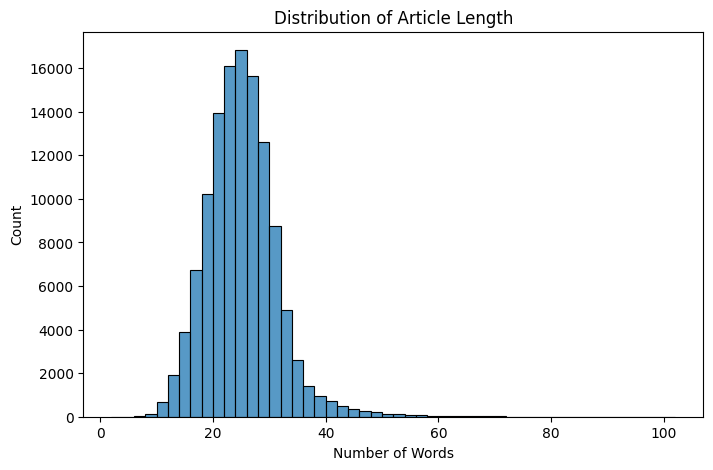


Average text length by category:


,text_length
category,
Business,25.16
Sci/Tech,24.42
Sports,23.53
World,25.36


In [28]:
train["text_length"] = train["clean_text"].str.split().str.len()

print(train["text_length"].describe())

plt.figure(figsize=(8,5))
sns.histplot(train["text_length"], bins=50)
plt.title("Distribution of Article Length")
plt.xlabel("Number of Words")
plt.show()

print("\nAverage text length by category:")
display(train.groupby("category")["text_length"].mean().round(2))

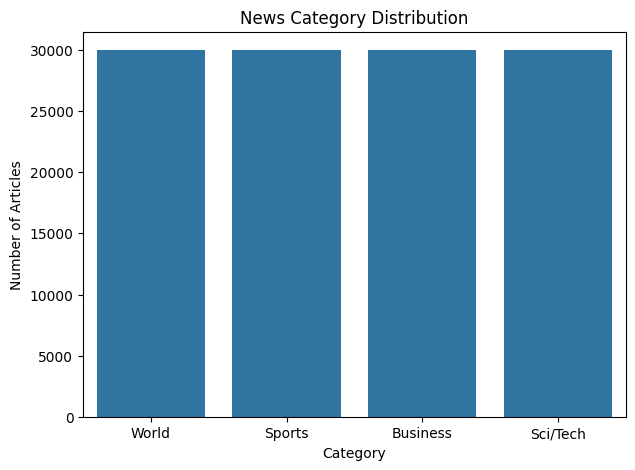

In [29]:
plt.figure(figsize=(7,5))
sns.countplot(data=train, x="category", order=label_map.values())
plt.title("News Category Distribution")
plt.xlabel("Category")
plt.ylabel("Number of Articles")
plt.show()

In [30]:
for category in label_map.values():
    words = " ".join(
        train.loc[train["category"] == category, "clean_text"]
    ).split()

    common = Counter(words).most_common(15)

    print(f"\n{category}:")
    print(common)


World:
[('said', 7745), ('iraq', 5876), ('reuters', 5423), ('president', 4349), ('minister', 3609), ('two', 3589), ('new', 3479), ('afp', 3388), ('killed', 3179), ('official', 3106), ('election', 3014), ('leader', 2987), ('say', 2924), ('people', 2886), ('iraqi', 2839)]

Sports:
[('game', 5938), ('win', 4380), ('first', 4253), ('team', 4163), ('new', 4160), ('season', 3855), ('year', 3853), ('two', 3348), ('one', 3268), ('night', 3135), ('world', 3038), ('last', 2867), ('league', 2797), ('victory', 2795), ('cup', 2778)]

Business:
[('said', 7311), ('reuters', 6903), ('new', 6632), ('oil', 6390), ('stock', 6157), ('company', 5481), ('price', 5365), ('year', 4500), ('inc', 4425), ('profit', 3730), ('percent', 3453), ('york', 3395), ('sale', 3350), ('corp', 3131), ('share', 3069)]

Sci/Tech:
[('new', 7154), ('microsoft', 5144), ('company', 4151), ('said', 3705), ('software', 3677), ('service', 3490), ('internet', 3398), ('year', 3373), ('reuters', 3276), ('computer', 2927), ('space', 268

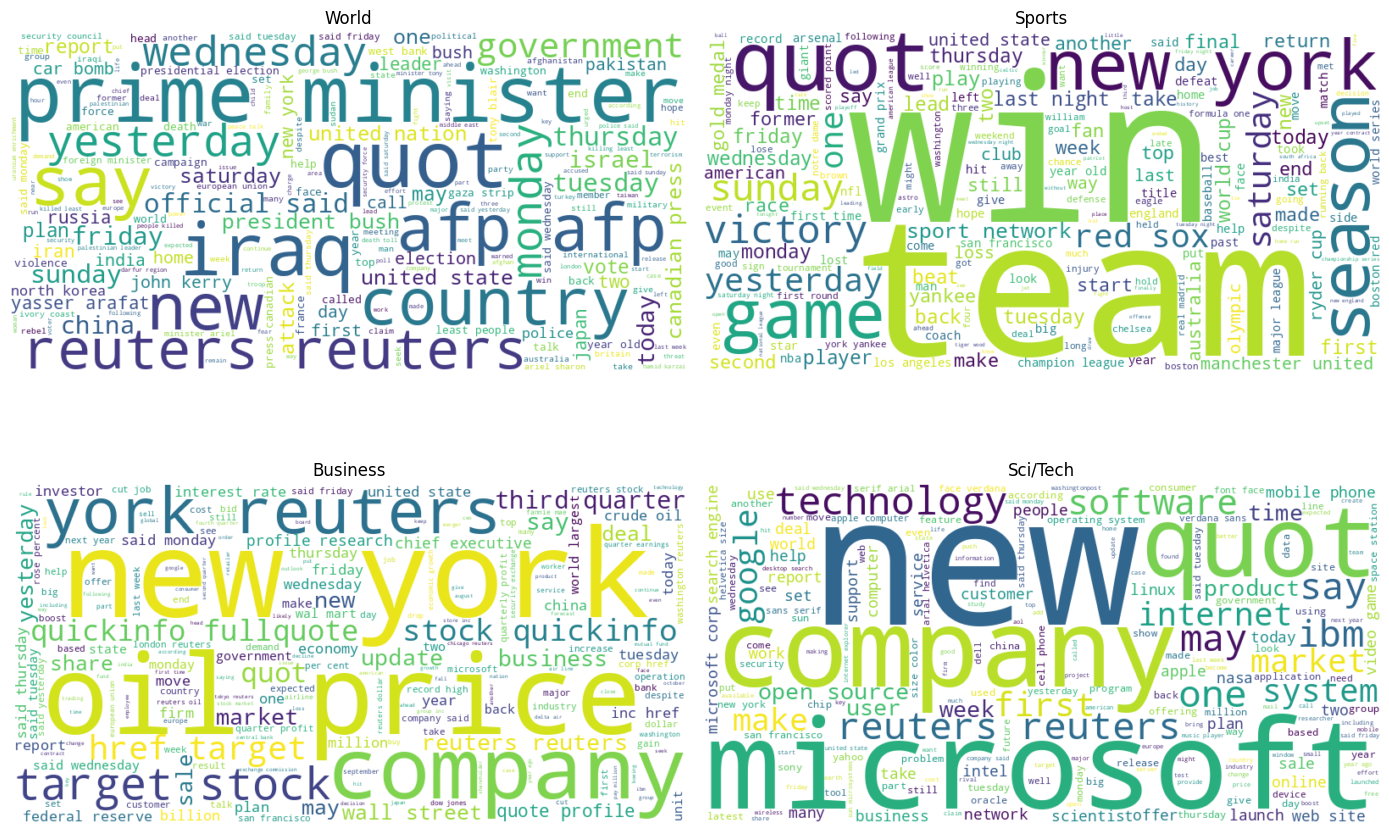

In [31]:
fig, axes = plt.subplots(2, 2, figsize=(14,10))

for ax, category in zip(axes.ravel(), label_map.values()):
    text = " ".join(
        train.loc[train["category"] == category, "clean_text"]
    )

    wc = WordCloud(width=800, height=400, background_color="white").generate(text)
    ax.imshow(wc, interpolation="bilinear")
    ax.set_title(category)
    ax.axis("off")

plt.tight_layout()
plt.show()

In [32]:
X_train, X_val, y_train, y_val = train_test_split(
    train["clean_text"],
    train["label"],
    test_size=0.20,
    random_state=42,
    stratify=train["label"]
)

print("Training samples:", len(X_train))
print("Validation samples:", len(X_val))

Training samples: 96000
Validation samples: 24000


In [33]:
X_train, X_val, y_train, y_val = train_test_split(
    train["clean_text"],
    train["label"],
    test_size=0.20,
    random_state=42,
    stratify=train["label"]
)

print("Training samples:", len(X_train))
print("Validation samples:", len(X_val))

Training samples: 96000
Validation samples: 24000


In [36]:
tfidf_bi = TfidfVectorizer(
    ngram_range=(1,2),
    min_df=2,
    max_df=0.95,
    max_features=150000,
    sublinear_tf=True
)

Xtr_bi = tfidf_bi.fit_transform(X_train)
Xval_bi = tfidf_bi.transform(X_val)

print(Xtr_bi.shape)

(96000, 150000)


In [37]:
lr_bi = LogisticRegression(
    C=4,
    max_iter=1000,
    random_state=42
)

lr_bi.fit(Xtr_bi, y_train)
pred_lr_bi = lr_bi.predict(Xval_bi)

In [41]:
nb_bi = MultinomialNB(alpha=0.1)
nb_bi.fit(Xtr_bi, y_train)

pred_nb_bi = nb_bi.predict(Xval_bi)

In [44]:
models = {
    "LR - Uni+Bi": pred_lr_bi,
    "NB - Uni+Bi": pred_nb_bi
}

results = []

for name, pred in models.items():
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_val, pred),
        "Precision": precision_score(y_val, pred, average="weighted"),
        "Recall": recall_score(y_val, pred, average="weighted"),
        "F1 Score": f1_score(y_val, pred, average="weighted")
    })

results_df = pd.DataFrame(results)
results_df = results_df.sort_values("F1 Score", ascending=False)

display(results_df.round(4))

,Model,Accuracy,Precision,Recall,F1 Score
0,LR - Uni+Bi,0.9212,0.9209,0.9212,0.9210
1,NB - Uni+Bi,0.9176,0.9174,0.9176,0.9174


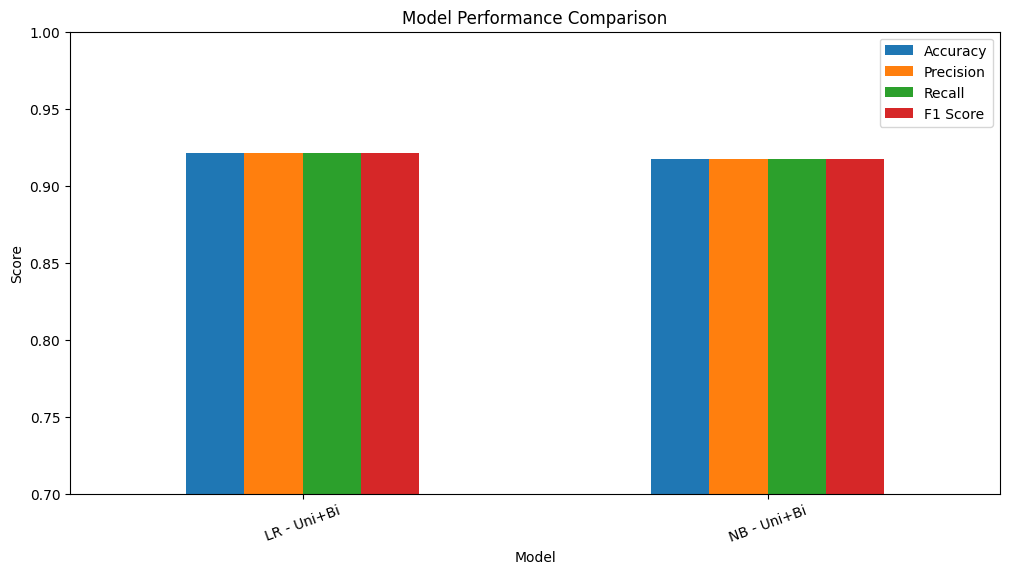

In [45]:
results_df.set_index("Model")[["Accuracy", "Precision", "Recall", "F1 Score"]].plot(
    kind="bar", figsize=(12,6)
)

plt.ylim(0.7, 1)
plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.xticks(rotation=20)
plt.show()

In [46]:
best_model_name = results_df.iloc[0]["Model"]
print("Best validation model:", best_model_name)

best_pred = models[best_model_name]

print(classification_report(
    y_val,
    best_pred,
    target_names=list(label_map.values())
))

Best validation model: LR - Uni+Bi
              precision    recall  f1-score   support

       World       0.93      0.91      0.92      6000
      Sports       0.96      0.98      0.97      6000
    Business       0.89      0.89      0.89      6000
    Sci/Tech       0.90      0.90      0.90      6000

    accuracy                           0.92     24000
   macro avg       0.92      0.92      0.92     24000
weighted avg       0.92      0.92      0.92     24000



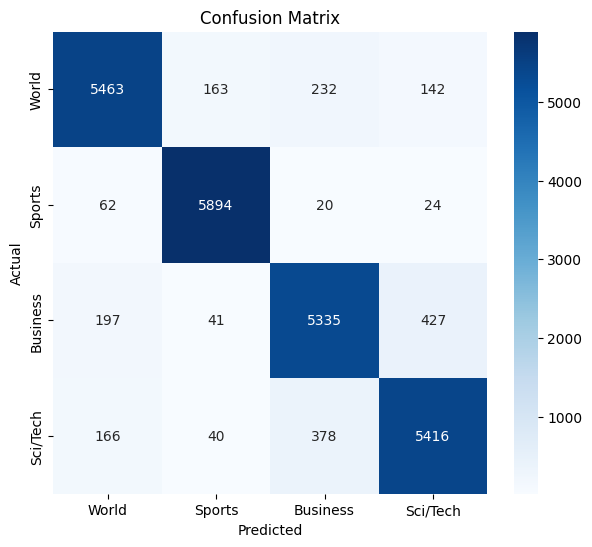

In [47]:
cm = confusion_matrix(y_val, best_pred)

plt.figure(figsize=(7,6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=label_map.values(),
    yticklabels=label_map.values()
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [48]:
report = classification_report(
    y_val,
    best_pred,
    target_names=list(label_map.values()),
    output_dict=True
)

recall_df = pd.DataFrame({
    category: report[category]["recall"]
    for category in label_map.values()
}, index=["Recall"]).T

display(recall_df.sort_values("Recall", ascending=False))

print("Highest recall:",
      recall_df["Recall"].idxmax())

print("Lowest recall:",
      recall_df["Recall"].idxmin())

,Recall
Sports,0.982333
World,0.910500
Sci/Tech,0.902667
Business,0.889167


Highest recall: Sports
Lowest recall: Business


In [49]:
cm_no_diag = cm.copy()
np.fill_diagonal(cm_no_diag, 0)

i, j = np.unravel_index(cm_no_diag.argmax(), cm_no_diag.shape)

print(
    f"Most confused categories: "
    f"{label_map[i+1]} -> {label_map[j+1]}"
)
print("Number of errors:", cm_no_diag[i, j])

Most confused categories: Business -> Sci/Tech
Number of errors: 427


In [50]:
world = label_map[1]
sports = label_map[2]
business = label_map[3]
tech = label_map[4]

print("Business ↔ World confusion:")
print(
    "Business predicted as World:",
    cm[2, 0]
)

print(
    "World predicted as Business:",
    cm[0, 2]
)

Business ↔ World confusion:
Business predicted as World: 197
World predicted as Business: 232


In [51]:
world = label_map[1]
sports = label_map[2]
business = label_map[3]
tech = label_map[4]

print("Business ↔ World confusion:")
print(
    "Business predicted as World:",
    cm[2, 0]
)

print(
    "World predicted as Business:",
    cm[0, 2]
)

Business ↔ World confusion:
Business predicted as World: 197
World predicted as Business: 232


In [52]:
final_vectorizer = TfidfVectorizer(
    ngram_range=(1,2),
    min_df=2,
    max_df=0.95,
    max_features=150000,
    sublinear_tf=True
)

X_all = final_vectorizer.fit_transform(train["clean_text"])
X_test = final_vectorizer.transform(test["clean_text"])

final_model = LogisticRegression(
    C=4,
    max_iter=1000,
    random_state=42
)

final_model.fit(X_all, train["label"])

print("Final model trained successfully!")

Final model trained successfully!


In [53]:
test_pred = final_model.predict(X_test)

print(classification_report(
    test["label"],
    test_pred,
    target_names=list(label_map.values())
))

print("Test Accuracy:",
      round(accuracy_score(test["label"], test_pred), 4))

print("Test Precision:",
      round(precision_score(test["label"], test_pred, average="weighted"), 4))

print("Test Recall:",
      round(recall_score(test["label"], test_pred, average="weighted"), 4))

print("Test F1:",
      round(f1_score(test["label"], test_pred, average="weighted"), 4))

              precision    recall  f1-score   support

       World       0.93      0.91      0.92      1900
      Sports       0.96      0.98      0.97      1900
    Business       0.89      0.89      0.89      1900
    Sci/Tech       0.90      0.91      0.90      1900

    accuracy                           0.92      7600
   macro avg       0.92      0.92      0.92      7600
weighted avg       0.92      0.92      0.92      7600

Test Accuracy: 0.9203
Test Precision: 0.9201
Test Recall: 0.9203
Test F1: 0.9201


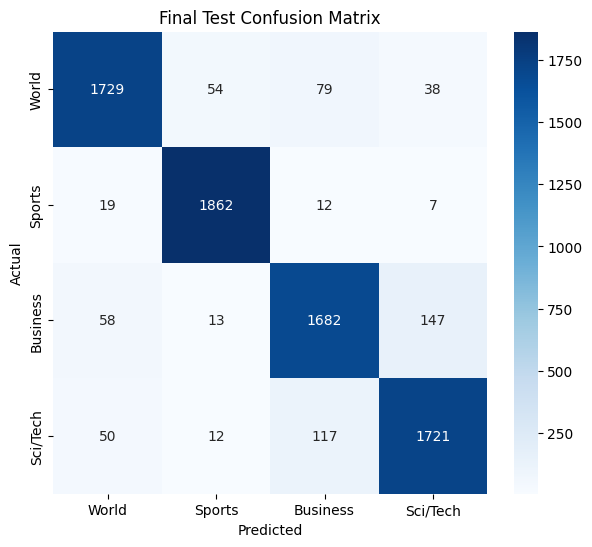

In [54]:
cm_test = confusion_matrix(test["label"], test_pred)

plt.figure(figsize=(7,6))
sns.heatmap(
    cm_test,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=label_map.values(),
    yticklabels=label_map.values()
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Final Test Confusion Matrix")
plt.show()

In [55]:
def predict_news(news):
    clean = preprocess(news)
    vector = final_vectorizer.transform([clean])

    prediction = final_model.predict(vector)[0]
    probability = final_model.predict_proba(vector)[0]

    category = label_map[prediction]
    confidence = probability.max() * 100

    return category, confidence

In [56]:
news = """
Apple has introduced a new artificial intelligence chip designed
to improve the performance of its next generation computers.
"""

category, confidence = predict_news(news)

print("News:", news)
print("Predicted Category:", category)
print(f"Confidence: {confidence:.2f}%")

News: 
Apple has introduced a new artificial intelligence chip designed
to improve the performance of its next generation computers.

Predicted Category: Sci/Tech
Confidence: 92.91%


In [ ]:
while True:
    news = input("\nEnter a news article (type 'exit' to stop): ")

    if news.lower() == "exit":
        break

    category, confidence = predict_news(news)

    print("\nPredicted Category:", category)
    print(f"Confidence: {confidence:.2f}%")


Enter a news article (type 'exit' to stop): The tennis player advanced to the tournament semifinals after winning a three-set match. She recorded nine aces and saved four break points during the contest.

Predicted Category: Sports
Confidence: 99.59%


In [59]:
def predict_news_details(news):
    clean = preprocess(news)
    vector = final_vectorizer.transform([clean])

    probabilities = final_model.predict_proba(vector)[0]

    result = pd.DataFrame({
        "Category": [label_map[i] for i in final_model.classes_],
        "Probability (%)": probabilities * 100
    })

    result = result.sort_values(
        "Probability (%)",
        ascending=False
    ).reset_index(drop=True)

    return result

In [60]:
new_articles = [
    ("The national government announced a new international agreement.",
     "World"),

    ("Leaders from several countries met to discuss global security.",
     "World"),

    ("The football team won the championship after a dramatic final.",
     "Sports"),

    ("The tennis player reached the final after winning three straight sets.",
     "Sports"),

    ("The company reported record quarterly revenue following strong sales.",
     "Business"),

    ("Stock markets rose after investors responded positively to the earnings report.",
     "Business"),

    ("Researchers developed a new artificial intelligence system for medical analysis.",
     "Sci/Tech"),

    ("The technology company launched a faster processor for AI applications.",
     "Sci/Tech")
]

prediction_results = []

for article, expected in new_articles:
    predicted, confidence = predict_news(article)

    prediction_results.append({
        "News Article": article,
        "Expected": expected,
        "Predicted": predicted,
        "Confidence": f"{confidence:.2f}%"
    })

new_results_df = pd.DataFrame(prediction_results)

display(new_results_df)

,News Article,Expected,Predicted,Confidence
0,The national government announced a new intern...,World,Sci/Tech,37.08%
1,Leaders from several countries met to discuss ...,World,World,80.62%
2,The football team won the championship after a...,Sports,Sports,99.97%
3,The tennis player reached the final after winn...,Sports,Sports,97.45%
4,The company reported record quarterly revenue ...,Business,Business,87.71%
5,Stock markets rose after investors responded p...,Business,Business,98.35%
6,Researchers developed a new artificial intelli...,Sci/Tech,Sci/Tech,85.56%
7,The technology company launched a faster proce...,Sci/Tech,Sci/Tech,95.86%


In [61]:
new_results_df["Correct"] = (
    new_results_df["Expected"] == new_results_df["Predicted"]
)

print("Correct predictions:",
      new_results_df["Correct"].sum())

print("Total articles:",
      len(new_results_df))

print("Accuracy:",
      new_results_df["Correct"].mean() * 100, "%")

display(new_results_df)

Correct predictions: 7
Total articles: 8
Accuracy: 87.5 %


,News Article,Expected,Predicted,Confidence,Correct
0,The national government announced a new intern...,World,Sci/Tech,37.08%,False
1,Leaders from several countries met to discuss ...,World,World,80.62%,True
2,The football team won the championship after a...,Sports,Sports,99.97%,True
3,The tennis player reached the final after winn...,Sports,Sports,97.45%,True
4,The company reported record quarterly revenue ...,Business,Business,87.71%,True
5,Stock markets rose after investors responded p...,Business,Business,98.35%,True
6,Researchers developed a new artificial intelli...,Sci/Tech,Sci/Tech,85.56%,True
7,The technology company launched a faster proce...,Sci/Tech,Sci/Tech,95.86%,True


In [62]:
joblib.dump(final_model, "agnews_model.pkl")
joblib.dump(final_vectorizer, "agnews_tfidf.pkl")
joblib.dump(label_map, "agnews_labels.pkl")

print("Model saved successfully!")

Model saved successfully!


In [63]:
from google.colab import files

files.download("agnews_model.pkl")
files.download("agnews_tfidf.pkl")
files.download("agnews_labels.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [64]:
for features in [30000, 50000, 100000]:
    vec = TfidfVectorizer(
        ngram_range=(1,2),
        max_features=features,
        min_df=2,
        max_df=0.95,
        sublinear_tf=True
    )

    xtr = vec.fit_transform(X_train)
    xv = vec.transform(X_val)

    model = LogisticRegression(C=4, max_iter=1000)
    model.fit(xtr, y_train)

    pred = model.predict(xv)

    print(
        features,
        "Accuracy:", round(accuracy_score(y_val, pred), 4),
        "F1:", round(f1_score(y_val, pred, average="weighted"), 4)
    )

30000 Accuracy: 0.9167 F1: 0.9166
50000 Accuracy: 0.919 F1: 0.9188
100000 Accuracy: 0.921 F1: 0.9208


In [66]:
news = input("Enter your news article: ")

category, confidence = predict_news(news)

print("Predicted Category:", category)
print(f"Confidence: {confidence:.2f}%")

Enter your news article: The tennis player advanced to the tournament semifinals after winning a three-set match. She recorded nine aces and saved four break points during the contest.
Predicted Category: Sports
Confidence: 99.59%
